# Attention analysis for PathFormer

This notebook is organized around attention analyses that can plausibly support a paper claim, rather than just producing isolated heatmaps.

## What is realistically interpretable here?

1. **Decoder self-attention over path history**
   - For each predicted path step, which previous path tokens does the model rely on?
   - Does later generation keep attending to the first dominant path?
   - Does the model prefer the most recent path token, or the strongest earlier path?

2. **Decoder cross-attention to the 4 prompt prefix tokens**
   - The corridor/codebook prompt is compressed into 4 learned prefix tokens before decoding.
   - We can inspect how strongly each predicted step attends to those 4 memory tokens.
   - We **cannot** attribute attention to individual raw RAG dimensions, because those dimensions are mixed before attention happens.

3. **Teacher-forced aggregate analysis over validation users**
   - This is more paper-ready than purely autoregressive rollout heatmaps.
   - Under teacher forcing, every source token corresponds to a true previous path, so attention summaries are easier to interpret.

## Most paper-useful candidate takeaways

- Later path predictions attend strongly to the **first / dominant previous path**, supporting the importance of stabilizing the first path.
- Attention to path history is not purely local; some layers retain long-range dependence on earlier dominant paths.
- Cross-attention to prompt memory is most structured early in generation, consistent with prompt-based initialization.

## Important limitation

Because the prompt is projected into **4 learned prefix tokens**, attention cannot tell us which exact corridor feature or codebook field mattered. If feature-level attribution is needed later, use gradients or ablations instead of attention alone.


In [1]:
import os
import types
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

os.chdir('/home/blessedg/Pathformer')
warnings.filterwarnings('ignore', category=UserWarning)

import deepmimo as dm
from dataset.dataloaders import PreTrainMySeqDataLoader
from multiscenario_direct_training_first_step_residual import (
    FirstStepResidualDataset,
    FirstStepResidualPathDecoder,
    load_best_checkpoint,
)
from multiscenario_direct_training_first_step_residual_corridor import (
    build_first_step_assignments_with_corridor,
)
from scene_feature_utils import SceneFeatureBank

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path('/home/blessedg/Pathformer')
PROJECT_ROOT


PosixPath('/home/blessedg/Pathformer')

## Configuration

The default configuration below uses the **raw foundation checkpoint** from the 27-scenario corridor-concat pretraining run.

Suggested experiments:
- Use a **seen** scenario such as `city_3_houston_3p5` or `city_23_beijing_3p5` for clean qualitative patterns.
- Use an **unseen** scenario such as `city_96_osaka_3p5` to see how the raw foundation model behaves out of distribution.
- Swap the checkpoint to a scenario-finetuned checkpoint to compare raw foundation vs finetuned attention structure.


In [2]:
CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints_first_step_residual_corridor_concat' / 'first_step_residual_corridor_concat_27scenarios_44710a4a_best_model_checkpoint.pth'
SCENARIO = 'city_23_beijing_3p5'
SPLIT = 'val'   # 'train' or 'val'
SAMPLE_INDEX = 0
MAX_AGGREGATE_SAMPLES = 128

MODEL_CONFIG = {
    'hidden_dim': 1024,
    'n_layers': 12,
    'n_heads': 8,
    'n_clusters': 25,
    'nearest_k': 5,
    'corridor_k': 5,
    'corridor_bins': 8,
    'use_material_features': True,
}

print('checkpoint:', CHECKPOINT_PATH)
print('scenario:', SCENARIO)
print('split:', SPLIT)


checkpoint: /home/blessedg/Pathformer/checkpoints_first_step_residual_corridor_concat/first_step_residual_corridor_concat_27scenarios_44710a4a_best_model_checkpoint.pth
scenario: city_23_beijing_3p5
split: val


In [3]:
def build_corridor_single_scenario_datasets(
    scenario,
    n_clusters=25,
    nearest_k=5,
    corridor_k=5,
    corridor_bins=8,
    use_material_features=True,
):
    dataset = dm.load(scenario)
    base_train = PreTrainMySeqDataLoader(
        dataset,
        train=True,
        split_by='user',
        sort_by='power',
        normalizers=None,
        apply_normalizers=[],
        pad_value=0,
        include_aod=True,
    )
    base_val = PreTrainMySeqDataLoader(
        dataset,
        train=False,
        split_by='user',
        sort_by='power',
        normalizers=None,
        apply_normalizers=[],
        pad_value=0,
        include_aod=True,
    )

    scene_bank = SceneFeatureBank.from_dataset(dataset, use_material_features=use_material_features)
    train_aug_prompts, train_baselines, val_aug_prompts, val_baselines = build_first_step_assignments_with_corridor(
        base_train,
        base_val,
        scene_bank,
        n_clusters=n_clusters,
        nearest_k=nearest_k,
        corridor_k=corridor_k,
        corridor_bins=corridor_bins,
    )

    prompt_dim = int(train_aug_prompts[0].numel())
    train_data = FirstStepResidualDataset(base_train, train_aug_prompts, train_baselines)
    val_data = FirstStepResidualDataset(base_val, val_aug_prompts, val_baselines)
    return {
        'dataset': dataset,
        'base_train': base_train,
        'base_val': base_val,
        'train_data': train_data,
        'val_data': val_data,
        'prompt_dim': prompt_dim,
    }


def load_corridor_model(checkpoint_path, prompt_dim, hidden_dim=1024, n_layers=12, n_heads=8):
    model = FirstStepResidualPathDecoder(
        prompt_dim=prompt_dim,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_heads=n_heads,
        include_aod=True,
    ).to(DEVICE)
    load_best_checkpoint(model, str(checkpoint_path))
    model.eval()
    return model


def collate_single(dataset_wrapper, idx):
    return dataset_wrapper.collate_fn([dataset_wrapper[idx]])


def get_gt_num_paths(path_lengths_tensor):
    return int(round(float(path_lengths_tensor.item()) * 25))


def rank_samples_by_num_paths(dataset_wrapper, top_k=10):
    rows = []
    for idx in range(len(dataset_wrapper)):
        batch = collate_single(dataset_wrapper, idx)
        _, paths, path_lengths, *_ = batch
        gt_len = get_gt_num_paths(path_lengths)
        max_power = float(paths[0, 1:1 + gt_len, 1].max().item()) if gt_len > 0 else float('-inf')
        rows.append({'sample_index': idx, 'gt_num_paths': gt_len, 'max_power_scaled': max_power})
    df = pd.DataFrame(rows)
    return df.sort_values(['gt_num_paths', 'max_power_scaled'], ascending=[False, False]).head(top_k)


In [4]:
def _make_attn_hook(store, layer_idx, kind):
    def _hook(module, inputs, output):
        # output = (attn_output, attn_weights) once need_weights=True is enforced.
        store[kind][layer_idx] = output[1].detach().cpu()
    return _hook


def enable_decoder_attention_capture(model):
    """
    Patches TransformerDecoderLayer self-attention and cross-attention modules so they always
    return per-head attention weights. Returns capture dict + cleanup handles.
    """
    store = {'self': {}, 'cross': {}}
    handles = []
    originals = []

    for layer_idx, layer in enumerate(model.backbone.decoder.layers):
        for kind, module in [('self', layer.self_attn), ('cross', layer.multihead_attn)]:
            original_forward = module.forward

            def patched_forward(self, *args, __orig=original_forward, **kwargs):
                kwargs.pop('need_weights', None)
                kwargs['need_weights'] = True
                kwargs['average_attn_weights'] = False
                return __orig(*args, **kwargs)

            module.forward = types.MethodType(patched_forward, module)
            originals.append((module, original_forward))
            handles.append(module.register_forward_hook(_make_attn_hook(store, layer_idx, kind)))

    return store, handles, originals


def restore_decoder_attention_capture(handles, originals):
    for handle in handles:
        handle.remove()
    for module, original_forward in originals:
        module.forward = original_forward


@torch.no_grad()
def run_teacher_forced_attention(model, batch):
    prompts, paths, path_lengths, interactions, env, env_prop, path_padding_mask, first_step_baselines = batch
    prompts = prompts.to(DEVICE)
    paths = paths.to(DEVICE)
    interactions = interactions.to(DEVICE)
    first_step_baselines = first_step_baselines.to(DEVICE)

    paths_in = paths[:, :-1, :]
    interactions_in = interactions[:, :-1, :]

    capture, handles, originals = enable_decoder_attention_capture(model)
    try:
        _ = model(prompts, paths_in, interactions_in, first_step_baselines)
    finally:
        restore_decoder_attention_capture(handles, originals)

    return {
        'self_attn': capture['self'],
        'cross_attn': capture['cross'],
        'paths': paths.detach().cpu(),
        'paths_in': paths_in.detach().cpu(),
        'path_lengths': path_lengths.detach().cpu(),
    }


In [5]:
def extract_attention_rows(attn_run, sample_pos=0):
    gt_len = get_gt_num_paths(attn_run['path_lengths'][sample_pos:sample_pos+1])
    if gt_len <= 0:
        return pd.DataFrame()

    paths = attn_run['paths'][sample_pos]
    paths_in = attn_run['paths_in'][sample_pos]
    rows = []

    for layer_idx in sorted(attn_run['self_attn']):
        self_w = attn_run['self_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :gt_len]
        cross_w = attn_run['cross_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :]

        for q in range(gt_len):
            row = {
                'layer': layer_idx,
                'query_path_index': q + 1,
                'cross_prefix_0': float(cross_w[q, 0]),
                'cross_prefix_1': float(cross_w[q, 1]),
                'cross_prefix_2': float(cross_w[q, 2]),
                'cross_prefix_3': float(cross_w[q, 3]),
                'cross_entropy': float(-(cross_w[q] * np.log(np.clip(cross_w[q], 1e-12, None))).sum()),
                'self_sos': float(self_w[q, 0]),
            }

            if q == 0:
                row.update(
                    {
                        'self_first_prev': np.nan,
                        'self_recent_prev': np.nan,
                        'self_dominant_prev': np.nan,
                        'self_other_prev_total': np.nan,
                        'first_prev_is_dominant': np.nan,
                    }
                )
            else:
                row['self_first_prev'] = float(self_w[q, 1])
                row['self_recent_prev'] = float(self_w[q, q])

                prev_powers = paths_in[1 : q + 1, 1]
                dominant_rel_idx = int(torch.argmax(prev_powers).item())
                dominant_src_idx = 1 + dominant_rel_idx
                row['self_dominant_prev'] = float(self_w[q, dominant_src_idx])
                row['first_prev_is_dominant'] = bool(dominant_src_idx == 1)

                other_indices = [i for i in range(1, q + 1) if i not in {1, q, dominant_src_idx}]
                row['self_other_prev_total'] = float(self_w[q, other_indices].sum()) if other_indices else 0.0

            rows.append(row)

    return pd.DataFrame(rows)


def plot_attention_heatmaps(attn_run, layer_idx=-1, sample_pos=0):
    gt_len = get_gt_num_paths(attn_run['path_lengths'][sample_pos:sample_pos+1])
    available_layers = sorted(attn_run['self_attn'])
    layer_idx = available_layers[layer_idx] if layer_idx < 0 else layer_idx

    self_w = attn_run['self_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :gt_len]
    cross_w = attn_run['cross_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(self_w, cmap='mako', ax=axes[0])
    axes[0].set_title(f'Self-attention heatmap | layer {layer_idx}')
    axes[0].set_xlabel('Source token index (0 = SOS, 1 = first path, ...)')
    axes[0].set_ylabel('Predicted path index - 1')

    sns.heatmap(cross_w, cmap='viridis', ax=axes[1])
    axes[1].set_title(f'Cross-attention to 4 prefix tokens | layer {layer_idx}')
    axes[1].set_xlabel('Prefix token index')
    axes[1].set_ylabel('Predicted path index - 1')
    plt.tight_layout()
    plt.show()



def aggregate_attention_statistics(model, dataset_wrapper, sample_indices):
    frames = []
    for idx in tqdm(sample_indices):
        batch = collate_single(dataset_wrapper, int(idx))
        attn_run = run_teacher_forced_attention(model, batch)
        frame = extract_attention_rows(attn_run, sample_pos=0)
        frame['sample_index'] = int(idx)
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def plot_bucket_curves(attn_df, layer_idx=-1):
    available_layers = sorted(attn_df['layer'].unique())
    layer_idx = available_layers[layer_idx] if layer_idx < 0 else layer_idx
    plot_df = attn_df[attn_df['layer'] == layer_idx].copy()
    grouped = plot_df.groupby('query_path_index')[['self_first_prev', 'self_recent_prev', 'self_dominant_prev', 'self_other_prev_total']].mean()

    plt.figure(figsize=(9, 5))
    for col in grouped.columns:
        plt.plot(grouped.index, grouped[col], marker='o', label=col)
    plt.title(f'Self-attention buckets by predicted path index | layer {layer_idx}')
    plt.xlabel('Predicted path index')
    plt.ylabel('Average attention weight')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    prefix_df = plot_df.groupby('query_path_index')[['cross_prefix_0', 'cross_prefix_1', 'cross_prefix_2', 'cross_prefix_3', 'cross_entropy']].mean()
    plt.figure(figsize=(9, 5))
    for col in ['cross_prefix_0', 'cross_prefix_1', 'cross_prefix_2', 'cross_prefix_3']:
        plt.plot(prefix_df.index, prefix_df[col], marker='o', label=col)
    plt.title(f'Cross-attention to prefix tokens by predicted path index | layer {layer_idx}')
    plt.xlabel('Predicted path index')
    plt.ylabel('Average attention weight')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(prefix_df.index, prefix_df['cross_entropy'], marker='o')
    plt.title(f'Cross-attention entropy over prefix tokens | layer {layer_idx}')
    plt.xlabel('Predicted path index')
    plt.ylabel('Entropy')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [6]:
bundle = build_corridor_single_scenario_datasets(
    SCENARIO,
    n_clusters=MODEL_CONFIG['n_clusters'],
    nearest_k=MODEL_CONFIG['nearest_k'],
    corridor_k=MODEL_CONFIG['corridor_k'],
    corridor_bins=MODEL_CONFIG['corridor_bins'],
    use_material_features=MODEL_CONFIG['use_material_features'],
)

dataset_wrapper = bundle['val_data'] if SPLIT == 'val' else bundle['train_data']
model = load_corridor_model(
    CHECKPOINT_PATH,
    prompt_dim=bundle['prompt_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    n_layers=MODEL_CONFIG['n_layers'],
    n_heads=MODEL_CONFIG['n_heads'],
)

print('split size:', len(dataset_wrapper))
print('prompt_dim:', bundle['prompt_dim'])
rank_samples_by_num_paths(dataset_wrapper, top_k=10)


Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 85988)
split size: 9205
prompt_dim: 136


,sample_index,gt_num_paths,max_power_scaled
4244,4244,25,-0.619687
8852,8852,25,-0.620922
2216,2216,25,-0.621388
3158,3158,25,-0.622307
8432,8432,25,-0.622755
8937,8937,25,-0.624605
3531,3531,25,-0.629532
6644,6644,25,-0.631662
6352,6352,25,-0.633190
4833,4833,25,-0.633570


In [7]:
batch = collate_single(dataset_wrapper, SAMPLE_INDEX)
attn_run = run_teacher_forced_attention(model, batch)
single_sample_df = extract_attention_rows(attn_run)

print('ground-truth number of paths:', get_gt_num_paths(attn_run['path_lengths']))
single_sample_df.head(12)


ground-truth number of paths: 24


,layer,query_path_index,cross_prefix_0,cross_prefix_1,cross_prefix_2,cross_prefix_3,cross_entropy,self_sos,self_first_prev,self_recent_prev,self_dominant_prev,self_other_prev_total,first_prev_is_dominant
0,0,1,0.496925,0.390456,0.112381,0.000238,0.962343,1.000000,NaN,NaN,NaN,NaN,NaN
1,0,2,0.374713,0.359867,0.011638,0.253782,1.135443,0.605147,0.394853,0.394853,0.394853,0.000000,True
2,0,3,0.126432,0.488798,0.131007,0.253762,1.225624,0.528307,0.165584,0.306108,0.165584,0.000000,True
3,0,4,0.042470,0.503573,0.213107,0.240850,1.151950,0.439531,0.087742,0.362296,0.087742,0.110431,True
4,0,5,0.131405,0.384400,0.233963,0.250232,1.320713,0.388118,0.052513,0.375087,0.052513,0.184282,True
5,0,6,0.174840,0.394452,0.289581,0.141127,1.307067,0.315468,0.042130,0.391241,0.042130,0.251161,True
6,0,7,0.254869,0.255903,0.258579,0.230650,1.385264,0.314147,0.033636,0.428342,0.033636,0.223875,True
7,0,8,0.360535,0.393963,0.113072,0.132429,1.248981,0.271759,0.023199,0.413478,0.023199,0.291564,True
8,0,9,0.228243,0.407662,0.130957,0.233139,1.308694,0.276821,0.024819,0.420776,0.024819,0.277584,True
9,0,10,0.147375,0.388229,0.196085,0.268312,1.321972,0.288126,0.020842,0.408851,0.020842,0.282182,True


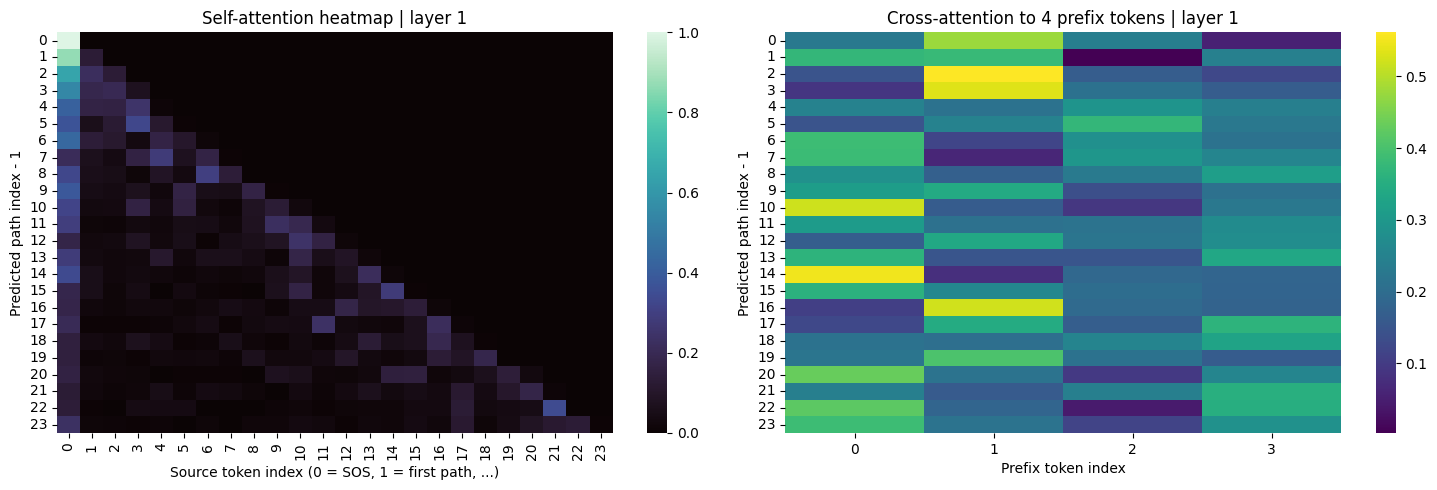

In [8]:
plot_attention_heatmaps(attn_run, layer_idx=1)


In [9]:
single_sample_df.groupby('query_path_index')[['self_first_prev', 'self_recent_prev', 'self_dominant_prev', 'cross_entropy']].mean()


,self_first_prev,self_recent_prev,self_dominant_prev,cross_entropy
query_path_index,,,,
1,NaN,NaN,NaN,1.255967
2,0.280974,0.280974,0.280974,1.227805
3,0.236036,0.236682,0.236036,1.207961
4,0.182120,0.186487,0.182120,1.225702
5,0.108498,0.218912,0.108498,1.303609
6,0.078004,0.109816,0.078004,1.259962
7,0.079384,0.119606,0.079384,1.303384
8,0.043373,0.116833,0.043373,1.271453
9,0.054572,0.129302,0.054572,1.288686


In [10]:
candidate_indices = rank_samples_by_num_paths(dataset_wrapper, top_k=MAX_AGGREGATE_SAMPLES)['sample_index'].tolist()
attn_df = aggregate_attention_statistics(model, dataset_wrapper, candidate_indices)
print('rows:', len(attn_df), '| samples:', attn_df['sample_index'].nunique())
attn_df.head()


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 94.86it/s]

rows: 38400 | samples: 128


,layer,query_path_index,cross_prefix_0,cross_prefix_1,cross_prefix_2,cross_prefix_3,cross_entropy,self_sos,self_first_prev,self_recent_prev,self_dominant_prev,self_other_prev_total,first_prev_is_dominant,sample_index
0,0,1,0.221612,0.500019,0.000002,0.278367,1.036500,1.000000,NaN,NaN,NaN,NaN,NaN,4244
1,0,2,0.192985,0.431192,0.000881,0.374941,1.054220,0.599400,0.400600,0.400600,0.400600,0.000000,True,4244
2,0,3,0.092180,0.464826,0.000083,0.442912,0.937334,0.609360,0.086614,0.304026,0.086614,0.000000,True,4244
3,0,4,0.131992,0.369120,0.143637,0.355252,1.281545,0.457984,0.085862,0.377750,0.085862,0.078404,True,4244
4,0,5,0.369371,0.250001,0.130563,0.250065,1.326862,0.420360,0.055543,0.381121,0.055543,0.142977,True,4244


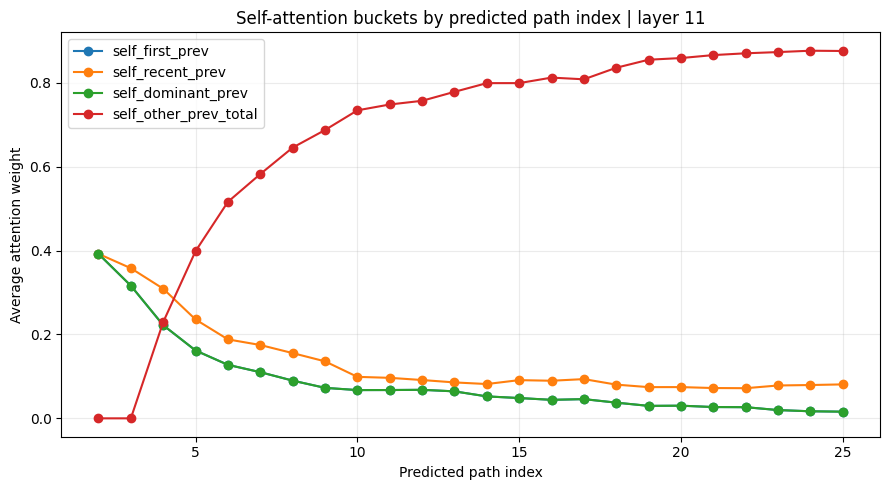

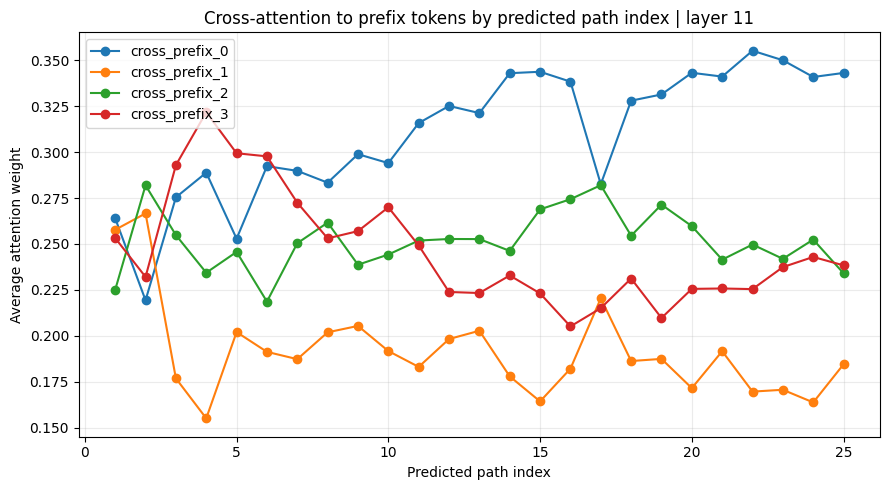

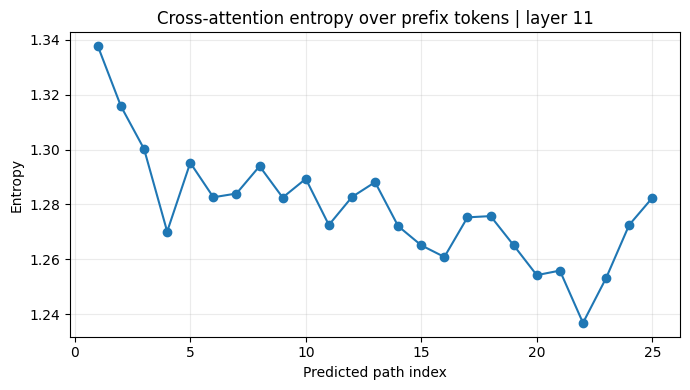

In [11]:
plot_bucket_curves(attn_df, layer_idx=-1)


## How to turn this into a paper figure

The strongest candidates are usually:

1. **Last-layer self-attention heatmap for one rich sample**
   - choose a sample with many valid paths
   - annotate that token `0` is SOS and token `1` is the first true path

2. **Aggregate bucket curves over many validation users**
   - show attention to `first_prev`, `recent_prev`, and `dominant_prev`
   - if `dominant_prev` stays large for later predictions, that supports the paper's dominant-path story

3. **Seen vs unseen comparison using the raw foundation checkpoint**
   - rerun this notebook on a seen scenario and an unseen scenario
   - compare whether self-attention remains structured or becomes much noisier out of distribution

### Practical caution

Do not overclaim that attention proves causal use of a feature. The safest phrasing is:

> "The observed attention patterns are consistent with the physical intuition that PathFormer relies on dominant early paths and prompt memory to stabilize later multipath generation."


In [12]:
# Optional comparison template:
# 1. Change CHECKPOINT_PATH to a finetuned scenario checkpoint.
# 2. Keep SCENARIO fixed.
# 3. Re-run the aggregate cells and compare the resulting curves.
#
# Example:
# CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints_first_step_residual_corridor_finetune' / 'first_step_residual_corridor_finetune_city_96_osaka_3p5_best_model_checkpoint.pth'
# SCENARIO = 'city_96_osaka_3p5'


In [13]:
cd /home/blessedg/Pathformer
python multiscenario_direct_training_first_step_residual_corridor_object_tokens.py \
  --scenario city_23_beijing_3p5

SyntaxError: invalid syntax (362016548.py, line 2)